## Estrátegia de Trade de Bitcoin

In [1]:
from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.tree      import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm       import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from sklearn.neural_network import MLPClassifier

# Para analise de dados e a avaliacao de modelos
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2, f_regression
)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# RNA
import tensorflow as tf
import keras

In [2]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pandas.plotting import scatter_matrix
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_model import ARIMA
import yfinance as yf

Uma das grande vantagem dos trades com criptomoedas é a volatilidade do mercados. Visto que os mercados de criptomoedas operam initerruptamente, acompanhar as posições em cripto perante uma dinamica do mercado tão variavel pode se tornar rapidamente uma tarefa impossivel de gerenciar

Diversos algoritmos de aprendizdo de maquina podem ser usadas para gerar sinais de trades numa tentativa de prever o movimento do mercado. É possivel usar algoritmos para classificar o movimento do dia seguinte em 3 categorias: 

* **Mercados subirão(assumir posiçao long)**
* **Mercados cairão(assumir posiçao short)**
* **Mercados andarão de lado(não assumir posição)**


### Definição do problema

O problema de prever um sinal de compra ou venda para uma estratégia de trades é definido no framework de classificação, em que variável prevista tem valor de 1 para compra e 0 para venda. Esse final é decidido por meio da comparação das tendencias deos preços de curto e longo prazos.

In [3]:
BTC = pd.read_csv('dataset\\btcusd_1-min_data.csv')
BTC.shape

(7176637, 6)

In [4]:
BTC['Timestamp'] = pd.to_datetime(BTC['Timestamp'], unit='s')

In [5]:
BTC.head()

,Timestamp,Open,High,Low,Close,Volume
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0


In [6]:
#Calculando volume
BTC['Volume'] = BTC['Volume'].astype(float)
BTC['Volume_btc'] = BTC['Volume']/BTC['Close']  

In [7]:
# Calculando VWAP
BTC['VWAP'] = (BTC['Close'] * BTC['Volume']).cumsum() / BTC['Volume'].cumsum()

In [8]:
BTC.head()

,Timestamp,Open,High,Low,Close,Volume,Volume_btc,VWAP
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0,0.0,NaN
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0,0.0,NaN
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0,0.0,NaN
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0,0.0,NaN
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0,0.0,NaN


**Indicadores de Volatilidade**
*  medem quanto o preço oscila em determinado período.

**Indicadores de Momentum**
* medem a velocidade da variação de preço (se o movimento está ganhando ou perdendo força).

**Indicadores de volume**
* analisam o número de negociações (quantidade de ativos transacionados)

**Indicadores de tedencia**
* mostram a direção predominante do preço (se está em alta, baixa ou lateral)

In [9]:
# Verificando NANS
BTC.isna().sum()

Timestamp       0
Open            0
High            0
Low             0
Close           0
Volume          0
Volume_btc      0
VWAP          627
dtype: int64

In [10]:
btc = BTC.dropna()

Criando as variavels alvo do modelo. Essa é a coluna que indicará se o sinal de tradeé compra ou venda.
> Curto prazo : media movvel dos 10 dias
>
> Longo prazo media movel de 60 dias

In [11]:
BTC['short'] = BTC['Close'].rolling(window=10, min_periods=1, center=False).mean()
BTC['long']  = BTC['Close'].rolling(window=60, min_periods=1, center=False).mean()

* window=10: significa que cada cálculo vai usar os últimos 10 fechamentos.

* min_periods=1: mesmo que a janela ainda não tenha 10 valores (ex.: nos primeiros dias), ele já calcula a média usando os que existirem.

* center=False: a janela não fica centralizada; ela “anda” para frente, ou seja, a média no índice t é calculada usando os valores até o tempo t (e não centralizando no meio da janela).

In [12]:
BTC['Signal'] = np.where(BTC['short'] > BTC['long'], 1, 0)

> Anexando um rotulo se o preço curto é mais alto que o preço de longo prazo

In [13]:
BTC['Signal'].value_counts()

Signal
0    3591936
1    3584701
Name: count, dtype: int64

Engenharia de features

Oscilador estocastico
* é um indicador de momentum que compara o preço de fechamento de um ativo com uma gama de seus preços anteriores ao longo de certo período. %K e %D são indicadores lento e rápidp. O indicadores rápido é mais sensivel do que o lento as mudanças no preço de uma ativo subjacente e provavelmente resultará em muitos sinais de transações

Indice de força relativa
* é um indicador de momentum que mensura a magnitude de mudanças recentes no preço para avaliar condições de sobrecomprado ou no preço de uma ação de outro ativo

Taxa de variação 
* É um oscilador de momentum que mede a porcentagem de mudança entre o preço atual e o periodo n de preços passados. 

Momentum
* É a taxa de aceleração do preço ou do volume de uma ativo mobiliario - ou seja, a velocidade na qual o preço está mudando.


In [14]:
# Média movel exponencial

def ema(data, n):
    return pd.Series(data['Close'].ewm(span=n, min_periods=n).mean(), name='ema_' + str(n))

* span=10 → define o “comprimento” da média (equivalente a 10 períodos).


* .mean() → calcula a média exponencial.

In [15]:
BTC['EMA_10'] = ema(BTC, 10)

In [16]:
BTC['EMA_30'] = ema(BTC, 30) 

In [17]:
BTC['EMA_200'] = ema(BTC, 200)

In [18]:
# Calculo da taxa de variação
def ROC(data, n):
    M = data.diff(n - 1)
    N = data.shift(n - 1)

    return pd.Series((M/N)*100, name='ROC_'+str(n))

In [19]:
BTC['ROC_10'] = ROC(BTC['Close'], 10)
BTC['ROC_30'] = ROC(BTC['Close'], 30)

In [20]:
# Calculo de momentum do preço
def MON(data, n):
    return pd.Series(data.diff(n), name='MON_'+str(n))

In [21]:
BTC['MON_10'] = MON(BTC['Close'], 10)
BTC['MON_30'] = MON(BTC['Close'], 30)

In [22]:
# Calculo de indice de força relativa
def RSI(data, period):
    delta = data.diff().dropna()
    u  = delta * 0
    d  = u.copy()
    
    u  = pd.Series(u)
    d  = pd.Series(d)

    u[delta > 0] = delta[delta > 0]
    d[delta < 0] = -delta[delta < 0]

    u[u.index[period - 1]] = np.mean(u[:period]) # primeiro vlaor é a soma dos ganhos médio
    u = u.drop(u.index[:(period - 1)])

    d[d.index[period - 1]] = np.mean(d[:period]) # primeiro vlaor é a soma das perdas médio
    d = d.drop(d.index[:(period - 1)])
    
    rs = u.ewm(com=period-1, adjust=False).mean() / d.ewm(com=period-1, adjust=False).mean() 

    return 100 - 100 / (1 + rs)

In [23]:
BTC['RSI_10'] = RSI(BTC['Close'], 10)
BTC['RSI_30'] = RSI(BTC['Close'], 30)
BTC['RSI_200'] = RSI(BTC['Close'], 200)

In [24]:
# Calculo do oscilador estocastico

def STOK(close, low, high, n):
    STOK_ = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
    return pd.Series(STOK_, name='STOK_'+str(n))

In [25]:
def STOD(close, low, high, n):
    STOD_ = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
    return pd.Series(STOD_, name='STOD_'+str(n)).rolling(3).mean()

In [26]:
BTC['%K10'] = STOK(BTC['Close'], BTC['Low'], BTC['High'], 10)
BTC['%D10'] = STOD(BTC['Close'], BTC['Low'], BTC['High'], 10)
BTC['%K30'] = STOK(BTC['Close'], BTC['Low'], BTC['High'], 30)
BTC['%D30'] = STOD(BTC['Close'], BTC['Low'], BTC['High'], 30)
BTC['%K200'] = STOK(BTC['Close'], BTC['Low'], BTC['High'], 200)
BTC['%D200'] = STOD(BTC['Close'], BTC['Low'], BTC['High'], 200)

In [27]:
def MA(data, n):
    return pd.Series(data.rolling(n).mean(), name='MA_'+str(n))

In [28]:
BTC['MA21'] = MA(BTC['Close'], 10)
BTC['MA63'] = MA(BTC['Close'], 30)
BTC['MA200'] = MA(BTC['Close'], 200)

In [29]:
#BTC.corrwith(BTC['Signal']).sort_values(ascending=False)

In [30]:
#BTC = BTC.set_index('Timestamp')

In [31]:
BTC = BTC.drop(columns=['Timestamp'])

Usando 100mil instancias para obter calculos mais rapidos

In [32]:
subset = BTC.iloc[-100_000:]

X = subset.drop('Signal', axis=1)
y = subset['Signal']

In [33]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)

In [34]:
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((80000, 28), (20000, 28), (80000,), (20000,))

In [35]:
num_folds = 10
scoring   = 'accuracy'

In [36]:
models = [
    ('RF', RandomForestClassifier()),
    ('LR', LogisticRegression()),
    ('CART', DecisionTreeClassifier()),
    ('GBM', GradientBoostingClassifier()),
    ('MLP', MLPClassifier()),
    ('AB', AdaBoostClassifier( estimator=LogisticRegression()))
]

In [37]:
train_results = []
test_results  = []
kfold_results = []
names  = []

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
import warnings
warnings.filterwarnings('ignore')
def evaluate_model(name, model):
    global names, kfold_result, test_result, train_result, num_folds, scoring
    

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_results = -1 * cross_val_score(model, xtrain, ytrain, cv=kfold , scoring=scoring)
    
    # Treina o modelo
    res = model.fit(xtrain, ytrain)
    
    
    pred_test = res.predict(xtest)
    pred_train =res.predict(xtrain)
    mse_test = accuracy_score(ytest, pred_test)
    mse_train = accuracy_score(ytrain, pred_train)
    
    names.append(name)
    kfold_result.append(cv_results)
    test_result.append(mse_test)
    train_result.append(mse_train)

> ta muito tempo

In [41]:
model = RandomForestClassifier()
model.fit(xtrain, ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
pred = model.predict(xtest)

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

In [44]:
confusion_matrix(ytest, pred)

array([[9468,  568],
       [ 659, 9305]])

In [45]:
print(classification_report(ytest, pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     10036
           1       0.94      0.93      0.94      9964

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



In [51]:
data_backest = pd.DataFrame(index=xtest.index)

In [52]:
data_backest['signal_pred'] = pred
data_backest['signal_true'] = ytest
data_backest['Market Return'] = xtest['Close'].pct_change()
data_backest['atual returns'] = data_backest['Market Return'] * data_backest['signal_true'].shift(1)
data_backest['Strategy returns'] = data_backest['Market Return'] * data_backest['signal_pred'].shift(1)

In [53]:
data_backest = data_backest.reset_index()


<Axes: >

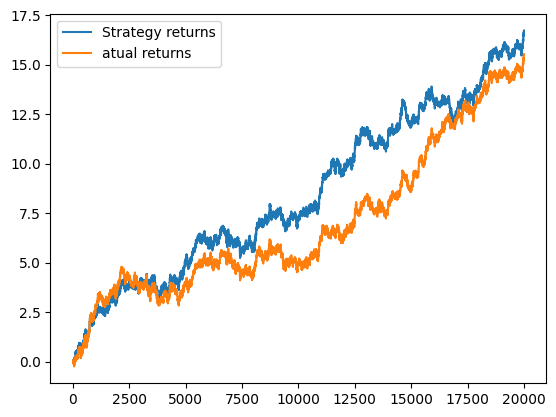

In [55]:
data_backest[['Strategy returns', 'atual returns']].cumsum().plot()

array([[<Axes: title={'center': 'Strategy returns'}>,
        <Axes: title={'center': 'atual returns'}>]], dtype=object)

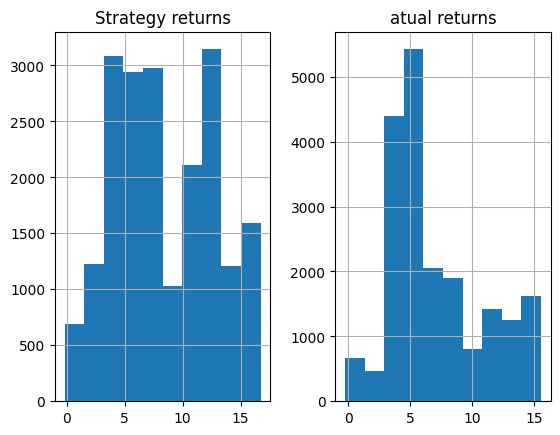

In [56]:
data_backest[['Strategy returns', 'atual returns']].cumsum().hist()